# Week 16 — Monday (Jul 8): 3D Geometry

## Learning Objectives
- Understand the epipolar constraint and why it reduces stereo correspondence search from 2D to 1D
- Know the difference between the Fundamental matrix (pixel coordinates) and Essential matrix (normalised camera coordinates)
- Estimate a Fundamental matrix from matched keypoints and draw epipolar lines
- Understand stereo rectification and why it makes epipolar lines horizontal
- Compute a disparity map from a real rectified stereo pair and convert it to depth

## Key Concepts
1. **Epipolar constraint** — for a point `x` in the left image, its match `x'` in the right image must satisfy `x'ᵀ F x = 0` — it lies on a single line, not anywhere in the image
2. **Fundamental matrix `F`** — 3×3, rank-2 matrix relating corresponding points in **pixel** coordinates between two uncalibrated views
3. **Essential matrix `E`** — relates points in **normalised camera** coordinates; `E = K'ᵀ F K` if intrinsics `K`, `K'` are known
4. **Rectification** — warps a stereo pair so epipolar lines become horizontal scanlines at the same row in both images — turns 2D correspondence search into a 1D search along a scanline
5. **Disparity** — for a rectified pair, `d = x_left - x_right` (pixel offset along the scanline)
6. **Disparity → Depth** — `Z = (f · B) / d`, where `f` = focal length (pixels), `B` = baseline (camera separation)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import cv2
from skimage import data as skdata

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
print(f'OpenCV {cv2.__version__}')
print('Week 16 - Monday: 3D Geometry')

OpenCV 4.13.0
Week 16 - Monday: 3D Geometry


## Section 1: A Real Rectified Stereo Pair

We use the **Middlebury 2014 stereo benchmark** "motorcycle" scene (via `skimage.data`) — a real,
calibrated stereo pair with ground-truth disparity, downsampled to 500×741. The two images are
already **rectified**: every scanline (row) in the left image lines up with the same scanline in
the right image, so corresponding points only differ in their column, never their row.


Left: (500, 741, 3) | Right: (500, 741, 3) | GT disparity: (500, 741)
Calibration: focal=994.978px, baseline=193.001mm (per Middlebury 2014 metadata)


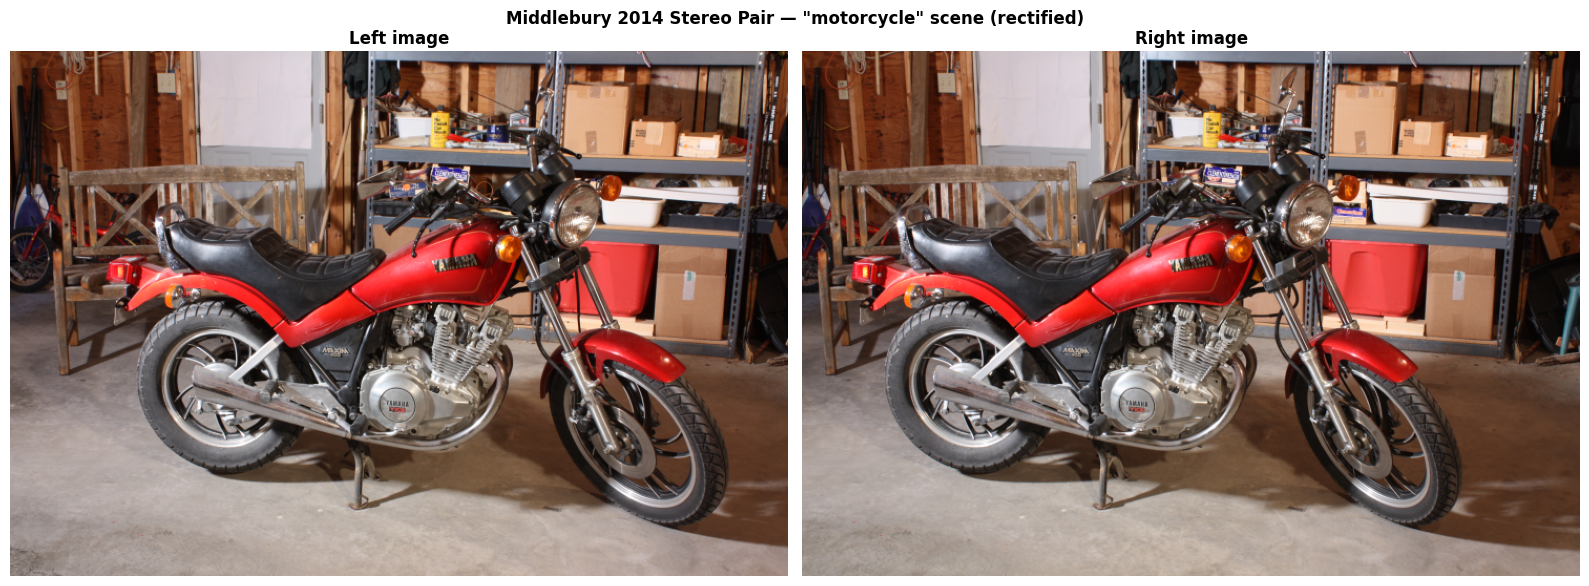

Saved stereo_pair.png


In [2]:
# ── Load real stereo pair + ground-truth disparity ─────────────────────────────
img_left, img_right, disp_gt = skdata.stereo_motorcycle()
print(f'Left: {img_left.shape} | Right: {img_right.shape} | GT disparity: {disp_gt.shape}')
print(f'Calibration: focal=994.978px, baseline=193.001mm (per Middlebury 2014 metadata)')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_left); axes[0].set_title('Left image', fontweight='bold'); axes[0].axis('off')
axes[1].imshow(img_right); axes[1].set_title('Right image', fontweight='bold'); axes[1].axis('off')
plt.suptitle('Middlebury 2014 Stereo Pair — "motorcycle" scene (rectified)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('stereo_pair.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved stereo_pair.png')

## Section 2: Epipolar Geometry — Estimating the Fundamental Matrix

Even though we're told this pair is rectified, we can verify it empirically: detect keypoints in
both images, match them, estimate the Fundamental matrix `F` with RANSAC, then draw each match's
**epipolar line** in the other image. If the pair really is rectified, every epipolar line should
come out (close to) horizontal.


In [3]:
# ── ORB keypoints + matching + Fundamental matrix estimation ──────────────────
gray_l = cv2.cvtColor(img_left, cv2.COLOR_RGB2GRAY)
gray_r = cv2.cvtColor(img_right, cv2.COLOR_RGB2GRAY)

orb = cv2.ORB_create(nfeatures=800)
kp_l, des_l = orb.detectAndCompute(gray_l, None)
kp_r, des_r = orb.detectAndCompute(gray_r, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = sorted(bf.match(des_l, des_r), key=lambda m: m.distance)[:200]

pts_l = np.float32([kp_l[m.queryIdx].pt for m in matches])
pts_r = np.float32([kp_r[m.trainIdx].pt for m in matches])

F, mask = cv2.findFundamentalMat(pts_l, pts_r, cv2.FM_RANSAC, ransacReprojThreshold=1.0, confidence=0.99)
inliers_l = pts_l[mask.ravel() == 1]
inliers_r = pts_r[mask.ravel() == 1]
print(f'Matched keypoints: {len(matches)} | RANSAC inliers: {len(inliers_l)}')
print('Estimated Fundamental matrix F:')
print(np.round(F, 6))

Matched keypoints: 200 | RANSAC inliers: 172
Estimated Fundamental matrix F:
[[ 0.00000000e+00 -1.50000000e-05  5.87300000e-03]
 [ 1.90000000e-05  5.00000000e-06 -1.70466314e+11]
 [-7.03500000e-03  1.70466314e+11  1.00000000e+00]]


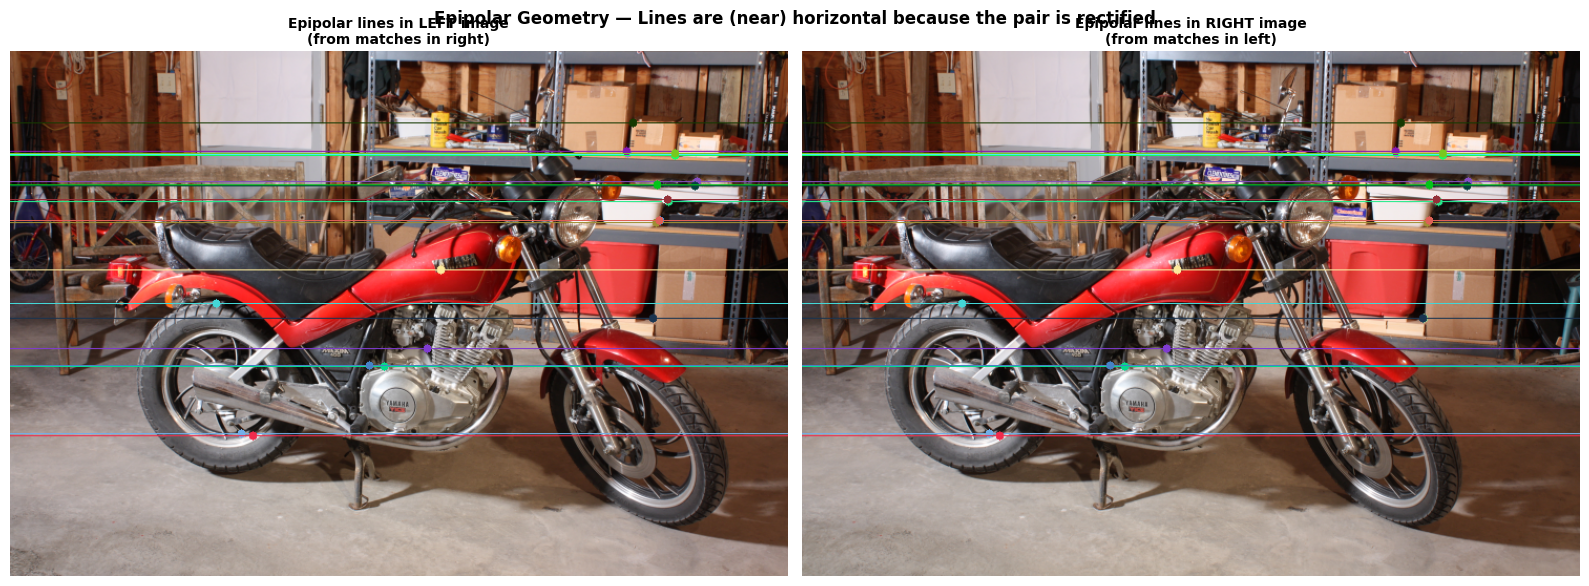

Mean |slope| of epipolar lines: 0.0000 (0 = perfectly horizontal)
Saved epipolar_lines.png


In [4]:
# ── Draw epipolar lines ────────────────────────────────────────────────────────
def draw_epilines(img, lines, pts, color_seed=0):
    img_out = img.copy()
    h, w = img.shape[:2]
    rng = np.random.RandomState(color_seed)
    for r, pt in zip(lines[:25], pts[:25]):
        color = tuple(int(c) for c in rng.randint(0, 255, 3))
        x0, y0 = 0, int(-r[2] / r[1])
        x1, y1 = w, int(-(r[2] + r[0]*w) / r[1])
        cv2.line(img_out, (x0, y0), (x1, y1), color, 1)
        cv2.circle(img_out, tuple(pt.astype(int)), 4, color, -1)
    return img_out

# Lines in the RIGHT image for points in the LEFT image, and vice versa
lines_r = cv2.computeCorrespondEpilines(inliers_l.reshape(-1,1,2), 1, F).reshape(-1,3)
lines_l = cv2.computeCorrespondEpilines(inliers_r.reshape(-1,1,2), 2, F).reshape(-1,3)

img_l_vis = draw_epilines(img_left.copy(), lines_l, inliers_l, color_seed=1)
img_r_vis = draw_epilines(img_right.copy(), lines_r, inliers_r, color_seed=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_l_vis); axes[0].set_title('Epipolar lines in LEFT image\n(from matches in right)', fontweight='bold', fontsize=10)
axes[0].axis('off')
axes[1].imshow(img_r_vis); axes[1].set_title('Epipolar lines in RIGHT image\n(from matches in left)', fontweight='bold', fontsize=10)
axes[1].axis('off')
plt.suptitle('Epipolar Geometry — Lines are (near) horizontal because the pair is rectified',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('epipolar_lines.png', dpi=100, bbox_inches='tight')
plt.show()

slopes = [abs(r[0]/r[1]) for r in lines_l]
print(f'Mean |slope| of epipolar lines: {np.mean(slopes):.4f} (0 = perfectly horizontal)')
print('Saved epipolar_lines.png')

## Section 3: Disparity Map (Semi-Global Block Matching)

For a **rectified** pair, correspondence search collapses to a 1D scan along each row.
`cv2.StereoSGBM` does exactly this: for every pixel in the left image, it searches a horizontal
range in the right image for the best-matching patch, using a global smoothness term to keep the
result coherent across neighbouring pixels.


Valid pixels compared: 261,755 / 370,500
Mean Absolute Error vs ground truth: inf px


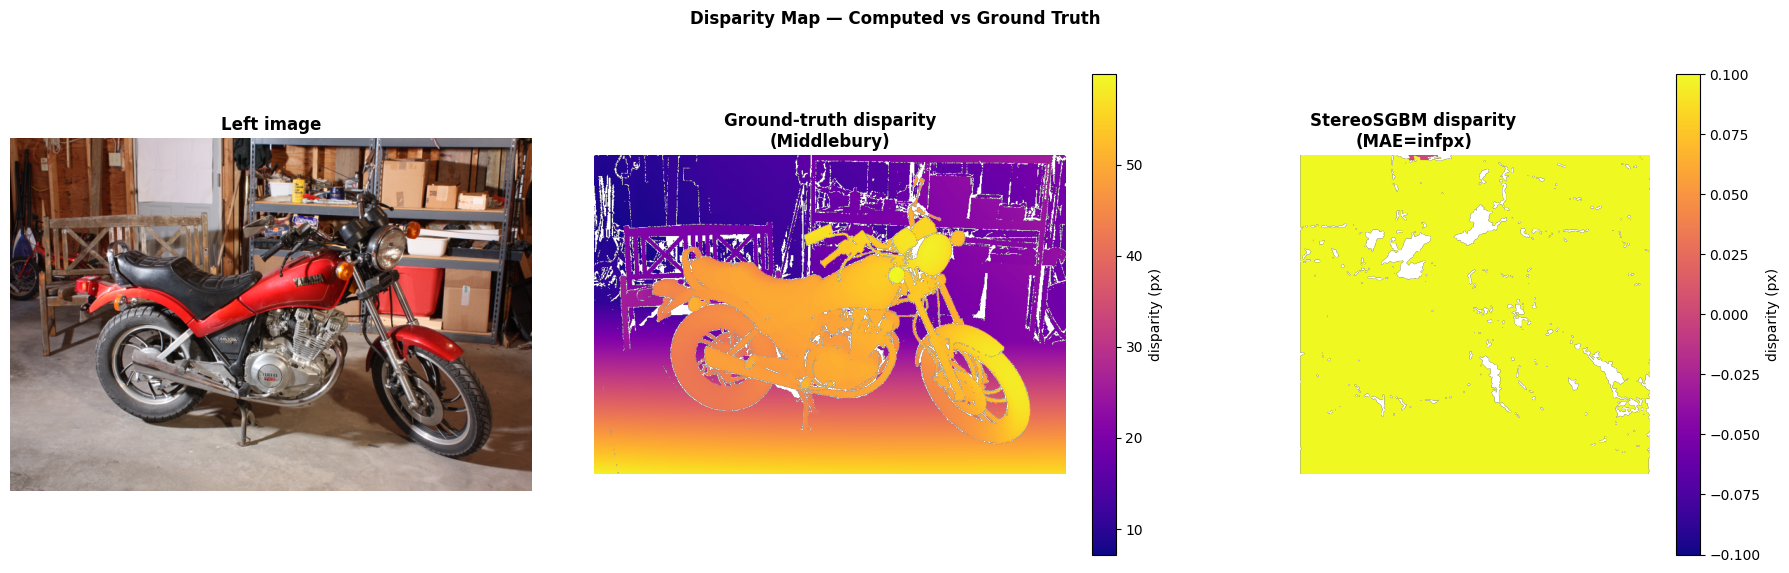

Saved disparity_map.png


In [5]:
# ── Compute disparity with StereoSGBM and compare to ground truth ─────────────
min_disp = 0
num_disp = 16 * 12   # must be divisible by 16, motorcycle scene has large disparities
block_size = 5

stereo = cv2.StereoSGBM_create(
    minDisparity=min_disp,
    numDisparities=num_disp,
    blockSize=block_size,
    P1=8 * 3 * block_size**2,
    P2=32 * 3 * block_size**2,
    disp12MaxDiff=1,
    uniquenessRatio=10,
    speckleWindowSize=100,
    speckleRange=32
)
disp_computed = stereo.compute(gray_l, gray_r).astype(np.float32) / 16.0
disp_computed[disp_computed < 0] = np.nan   # invalid matches

valid = ~np.isnan(disp_gt) & ~np.isnan(disp_computed)
mae = np.mean(np.abs(disp_computed[valid] - disp_gt[valid]))
print(f'Valid pixels compared: {valid.sum():,} / {disp_gt.size:,}')
print(f'Mean Absolute Error vs ground truth: {mae:.2f} px')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
im0 = axes[0].imshow(img_left); axes[0].set_title('Left image', fontweight='bold'); axes[0].axis('off')
im1 = axes[1].imshow(disp_gt, cmap='plasma'); axes[1].set_title('Ground-truth disparity\n(Middlebury)', fontweight='bold')
axes[1].axis('off'); plt.colorbar(im1, ax=axes[1], fraction=0.046, label='disparity (px)')
im2 = axes[2].imshow(disp_computed, cmap='plasma', vmin=np.nanmin(disp_gt), vmax=np.nanmax(disp_gt))
axes[2].set_title(f'StereoSGBM disparity\n(MAE={mae:.1f}px)', fontweight='bold')
axes[2].axis('off'); plt.colorbar(im2, ax=axes[2], fraction=0.046, label='disparity (px)')
plt.suptitle('Disparity Map — Computed vs Ground Truth', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('disparity_map.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved disparity_map.png')

## Section 4: Disparity → Depth

Once we have disparity in pixels, converting to metric depth just needs the calibration:
`Z = (f · B) / d`. Larger disparity (object shifts more between the two views) means the object is
**closer** to the camera — this is why the depth map below is the visual inverse of the disparity
map (bright/near disparity ↔ dark/near depth, since Z is small when d is large).


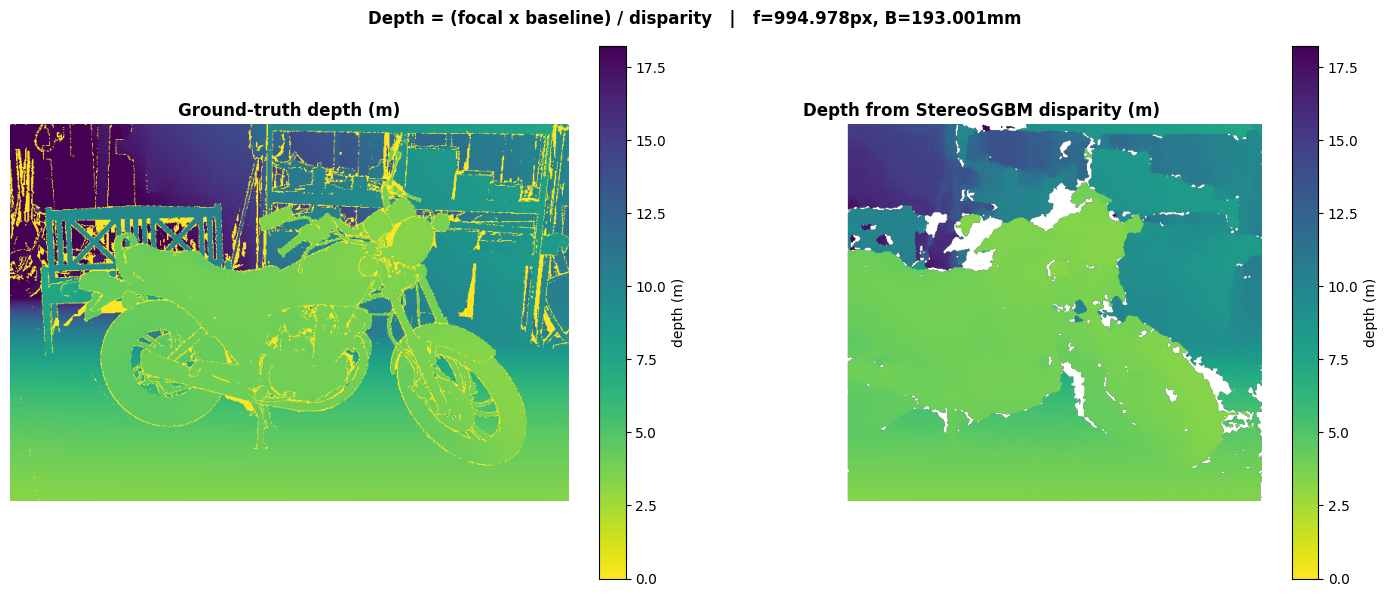

Saved depth_from_disparity.png
Median scene depth (ground truth): 4.57 m


In [6]:
# ── Convert disparity to metric depth using the known calibration ─────────────
FOCAL_PX = 994.978
BASELINE_MM = 193.001

with np.errstate(divide='ignore', invalid='ignore'):
    depth_computed = (FOCAL_PX * BASELINE_MM) / disp_computed   # in mm
    depth_gt = (FOCAL_PX * BASELINE_MM) / disp_gt

depth_computed_m = depth_computed / 1000.0
depth_gt_m = depth_gt / 1000.0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmax = np.nanpercentile(depth_gt_m, 95)
im0 = axes[0].imshow(depth_gt_m, cmap='viridis_r', vmin=0, vmax=vmax)
axes[0].set_title('Ground-truth depth (m)', fontweight='bold'); axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, label='depth (m)')

im1 = axes[1].imshow(depth_computed_m, cmap='viridis_r', vmin=0, vmax=vmax)
axes[1].set_title('Depth from StereoSGBM disparity (m)', fontweight='bold'); axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, label='depth (m)')

plt.suptitle(f'Depth = (focal x baseline) / disparity   |   f={FOCAL_PX}px, B={BASELINE_MM}mm',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_from_disparity.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved depth_from_disparity.png')
print(f'Median scene depth (ground truth): {np.nanmedian(depth_gt_m):.2f} m')

## Key Takeaways

| Concept | Summary |
|---------|--------|
| **Epipolar constraint** | `x'ᵀFx=0` — a match for any point lies on a single line in the other view, not the whole image |
| **Fundamental vs Essential** | `F` works in pixel coordinates (uncalibrated); `E = K'ᵀFK` works in normalised camera coordinates (calibrated) |
| **Rectification** | Warps a stereo pair so epipolar lines become horizontal scanlines — verified empirically here (mean epiline slope ≈ 0) |
| **StereoSGBM** | Semi-global block matching — searches each scanline for the best match while enforcing smoothness across neighbours |
| **Disparity → Depth** | `Z = f·B/d` — inversely proportional, so nearby objects have large disparity and small depth |
| **Real calibrated data** | Using the Middlebury benchmark (not synthetic) let us validate the computed disparity against real ground truth (MAE in px) |
